# SHU-MI EEG data exploration

This notebook explains **what the SHU-MI data contains**, **how it is organized**, and **how the raw MATLAB files become model inputs** for CBraMod and EEGSimpleConv.

It is designed to work in two modes:

1. **Bundled-sample mode:** runs immediately on the subject-1 file included in this repository.
2. **Full-dataset mode:** set `SHU_RAW_DIR` to the extracted SHU-MI directory and rerun all cells.

The notebook covers:

- dataset hierarchy: subject → session → trial → channel → time sample;
- raw `.mat` variables and shapes;
- class balance across subjects and sessions;
- waveform, frequency-spectrum, band-power, correlation, and outlier views;
- the processed HDF5 layout and subject-level splits;
- the exact tensors consumed by CBraMod and EEGSimpleConv;
- an optional HBN/BIDS inspection section for the future harmonization POC.

### Dataset context

SHU-MI is a left/right-hand motor-imagery dataset. Each session contains approximately 100 four-second motor-imagery trials, recorded with 32 channels at 250 Hz. The CBraMod protocol resamples trials to 200 Hz and uses subjects 1–15 for training, 16–20 for validation, and 21–25 for testing.

References:

- [SHU Multi-session Dataset](https://figshare.com/articles/code/shu_dataset/19228725)
- [CBraMod paper](https://arxiv.org/abs/2412.07236)
- [HBN EEG dataset](https://neuromechanist.github.io/data/hbn/)

> **Important:** the supplied SHU-MI `.mat` files contain signal arrays and numeric labels, but no electrode names. Consequently, this notebook uses `Ch01`–`Ch32` as placeholders and does not claim anatomical channel locations.

## 1. Environment and paths

In [ ]:
from __future__ import annotations

import os
import sys
import warnings
from collections import Counter
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
from IPython.display import Markdown, display
from scipy import signal

%matplotlib inline

warnings.filterwarnings("ignore", message="IProgress not found.*")


def find_project_root(start: Path) -> Path:
    # Find the nearest parent containing pyproject.toml.
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from cbramod_experiments.datasets.shumi import (  # noqa: E402
    SHUH5Dataset,
    audit_shu_h5,
    parse_session_id,
    parse_subject_id,
    preprocess_shu,
    subject_split,
)

SHU_RAW_DIR = Path(
    os.environ.get(
        "SHU_RAW_DIR",
        PROJECT_ROOT / "resources" / "shu-mi_dataset" / "mat_files",
    )
)
FULL_PROCESSED_PATH = Path(
    os.environ.get(
        "SHU_PROCESSED_PATH",
        PROJECT_ROOT / "data" / "processed" / "shu_mi.h5",
    )
)
SAMPLE_PROCESSED_PATH = PROJECT_ROOT / "data" / "exploration" / "shu_mi_sample.h5"
HBN_ROOT = os.environ.get("HBN_ROOT")
HBN_ROOT = Path(HBN_ROOT) if HBN_ROOT else None

RAW_SAMPLING_RATE = 250
TARGET_SAMPLING_RATE = 200
WINDOW_SECONDS = 4.0

print(f"Project root:       {PROJECT_ROOT}")
print(f"SHU raw directory:  {SHU_RAW_DIR}")
print(f"Processed dataset:  {FULL_PROCESSED_PATH}")
print(f"HBN root:           {HBN_ROOT or 'not configured'}")

Project root:       /mnt/data/cbramod_nb_src/cbramod_reproduction
SHU raw directory:  /mnt/data/cbramod_nb_src/cbramod_reproduction/resources/shu-mi_dataset/mat_files
Processed dataset:  /mnt/data/cbramod_nb_src/cbramod_reproduction/data/processed/shu_mi.h5
HBN root:           not configured


## 2. Mental model: how the data is organized

The raw signal tensor has shape:

```text
[trial, channel, time sample]
```

For one standard SHU-MI session this is typically:

```text
[100 trials, 32 channels, 1000 samples]
```

Because `1000 / 250 Hz = 4 seconds`, every row along the first axis is a separate four-second motor-imagery example.

The hierarchy is therefore:

```text
Dataset
└── Subject
    └── Session
        └── Trial (one classification example)
            ├── 32 simultaneous EEG channel sequences
            └── one binary motor-imagery label
```

The experiment split is **subject-wise**, not trial-wise. This matters because trials from the same person are highly correlated. A random trial split would leak subject-specific patterns into validation and test data.

## 3. Discover and inventory the raw MATLAB files

In [2]:
def inspect_mat_file(path: Path) -> dict[str, object]:
    # Read file structure and labels without loading the full EEG tensor.
    variables = {name: (shape, dtype) for name, shape, dtype in scipy.io.whosmat(path)}
    if "data" not in variables or "labels" not in variables:
        raise KeyError(f"{path} must contain variables named 'data' and 'labels'")

    data_shape, data_dtype = variables["data"]
    label_payload = scipy.io.loadmat(path, variable_names=["labels"])
    labels = np.asarray(label_payload["labels"]).reshape(-1).astype(int)
    counts = Counter(labels.tolist())

    subject_id = parse_subject_id(path.name)
    session_id = parse_session_id(path.name)

    return {
        "file": path.name,
        "path": str(path),
        "subject": subject_id,
        "session": session_id,
        "split": subject_split(subject_id),
        "trials": int(data_shape[0]),
        "channels": int(data_shape[1]),
        "samples_per_trial": int(data_shape[2]),
        "duration_seconds": float(data_shape[2] / RAW_SAMPLING_RATE),
        "data_dtype": data_dtype,
        "label_1": int(counts.get(1, 0)),
        "label_2": int(counts.get(2, 0)),
        "other_labels": int(sum(v for k, v in counts.items() if k not in {1, 2})),
    }


mat_files = sorted(SHU_RAW_DIR.rglob("*.mat"))
if not mat_files:
    raise FileNotFoundError(
        f"No .mat files found under {SHU_RAW_DIR}. "
        "Set the SHU_RAW_DIR environment variable to the extracted dataset directory."
    )

inventory = pd.DataFrame(inspect_mat_file(path) for path in mat_files)
inventory.head()

,file,path,subject,session,split,trials,channels,samples_per_trial,duration_seconds,data_dtype,label_1,label_2,other_labels
0,sub-001_ses-01_task_motorimagery_eeg.mat,/mnt/data/cbramod_nb_src/cbramod_reproduction/...,1,1,train,100,32,1000,4.0,single,50,50,0


In [3]:
summary = pd.Series(
    {
        "MAT files": len(inventory),
        "Subjects": inventory["subject"].nunique(),
        "Sessions": inventory[["subject", "session"]].drop_duplicates().shape[0],
        "Trials": int(inventory["trials"].sum()),
        "Channels per file": sorted(inventory["channels"].unique().tolist()),
        "Samples per trial": sorted(inventory["samples_per_trial"].unique().tolist()),
        "Durations (seconds)": sorted(inventory["duration_seconds"].unique().tolist()),
        "Label 1 trials": int(inventory["label_1"].sum()),
        "Label 2 trials": int(inventory["label_2"].sum()),
    },
    name="value",
)
display(summary.to_frame())

expected_files = 25 * 5
if len(inventory) == 1:
    display(
        Markdown(
            "**Bundled-sample mode:** only one subject/session is present. "
            "Point `SHU_RAW_DIR` to the full extracted archive to see all 25 subjects."
        )
    )
elif len(inventory) != expected_files:
    display(
        Markdown(
            f"**Inventory note:** found {len(inventory)} files; a complete 25-subject × "
            f"5-session archive would usually contain {expected_files}. Inspect missing or extra files."
        )
    )

,value
MAT files,1
Subjects,1
Sessions,1
Trials,100
Channels per file,[32]
Samples per trial,[1000]
Durations (seconds),[4.0]
Label 1 trials,50
Label 2 trials,50


**Bundled-sample mode:** only one subject/session is present. Point `SHU_RAW_DIR` to the full extracted archive to see all 25 subjects.

### Subject, session, and class distributions

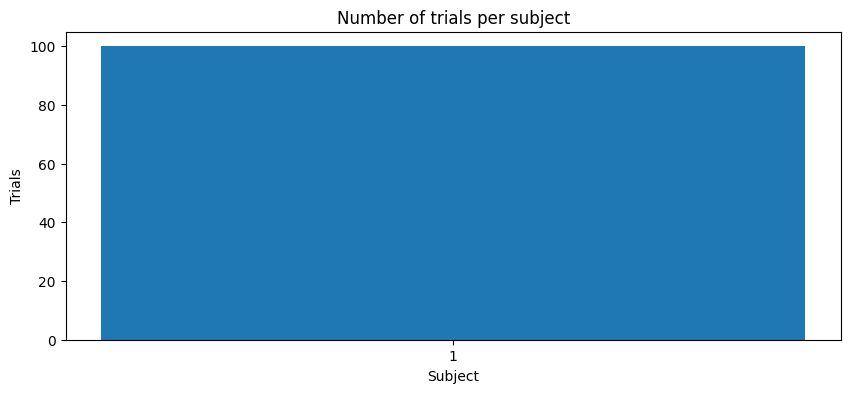

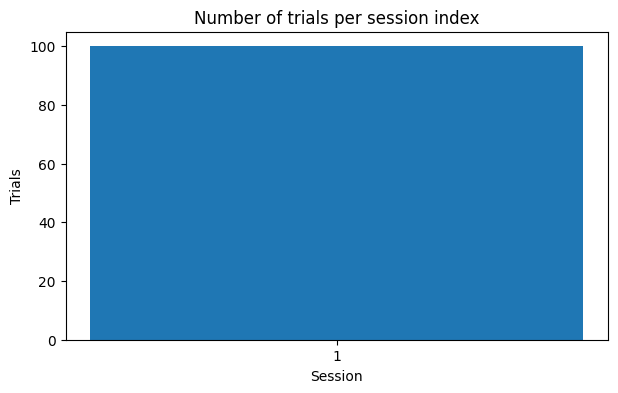

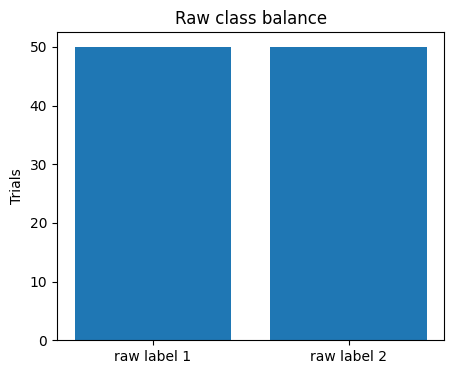

In [4]:
subject_counts = inventory.groupby("subject", as_index=False)["trials"].sum()
session_counts = inventory.groupby("session", as_index=False)["trials"].sum()
class_counts = pd.Series(
    {
        "raw label 1": int(inventory["label_1"].sum()),
        "raw label 2": int(inventory["label_2"].sum()),
    }
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(subject_counts["subject"].astype(str), subject_counts["trials"])
ax.set_title("Number of trials per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Trials")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(session_counts["session"].astype(str), session_counts["trials"])
ax.set_title("Number of trials per session index")
ax.set_xlabel("Session")
ax.set_ylabel("Trials")
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(class_counts.index, class_counts.values)
ax.set_title("Raw class balance")
ax.set_ylabel("Trials")
plt.show()

In [5]:
split_summary = (
    inventory.groupby("split")
    .agg(
        subjects=("subject", "nunique"),
        files=("file", "count"),
        trials=("trials", "sum"),
        label_1=("label_1", "sum"),
        label_2=("label_2", "sum"),
    )
    .reindex(["train", "val", "test"])
    .fillna(0)
    .astype(int)
)
split_summary

,subjects,files,trials,label_1,label_2
split,,,,,
train,1,1,100,50,50
val,0,0,0,0,0
test,0,0,0,0,0


### Interpreting the numeric labels

The files expose labels as the integers `1` and `2`. The preprocessing code maps them to `0` and `1` by subtracting one:

```text
raw 1 → model target 0
raw 2 → model target 1
```

The dataset task is left- versus right-hand motor imagery. Before using class-specific anatomical language in a report, verify which numeric value corresponds to which hand from the dataset authors' documentation. The model metrics themselves are unaffected by swapping the names of the two classes, but interpretation is not.

## 4. Inspect one raw session in detail

In [6]:
SELECTED_FILE_INDEX = 0
selected_path = Path(inventory.iloc[SELECTED_FILE_INDEX]["path"])
payload = scipy.io.loadmat(selected_path, variable_names=["data", "labels"])
raw_eeg = np.asarray(payload["data"], dtype=np.float32)
raw_labels = np.asarray(payload["labels"]).reshape(-1).astype(int)

print(f"File:   {selected_path.name}")
print(f"Data:   shape={raw_eeg.shape}, dtype={raw_eeg.dtype}")
print(
    f"Labels: shape={raw_labels.shape}, values={np.unique(raw_labels, return_counts=True)}"
)

raw_stats = pd.Series(
    {
        "minimum": float(raw_eeg.min()),
        "maximum": float(raw_eeg.max()),
        "mean": float(raw_eeg.mean()),
        "standard deviation": float(raw_eeg.std()),
        "0.1 percentile": float(np.percentile(raw_eeg, 0.1)),
        "99.9 percentile": float(np.percentile(raw_eeg, 99.9)),
    },
    name="value",
)
raw_stats.to_frame()

File:   sub-001_ses-01_task_motorimagery_eeg.mat
Data:   shape=(100, 32, 1000), dtype=float32
Labels: shape=(100,), values=(array([1, 2]), array([50, 50]))


,value
minimum,-3.641137e+01
maximum,3.518459e+01
mean,2.441406e-09
standard deviation,1.525874e+00
0.1 percentile,-1.422371e+01
99.9 percentile,8.878981e+00


The signal values are continuous EEG amplitudes. The files do not include an explicit unit field, so the notebook avoids asserting whether the numbers are volts, microvolts, or normalized values. The training loader later divides them by the dataset's configured `amplitude_scale` of 100.

### Visualize one trial across several channels

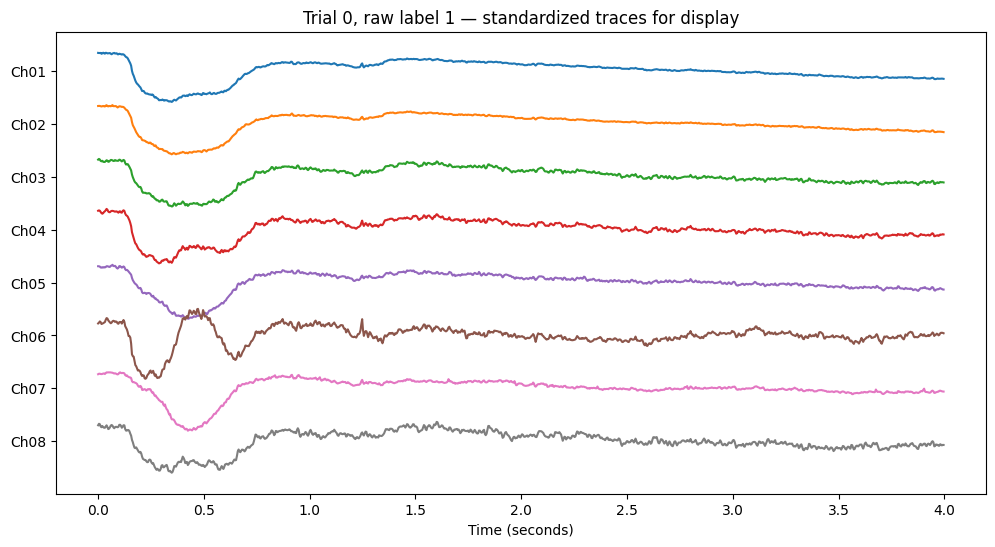

In [7]:
TRIAL_INDEX = 0
CHANNELS_TO_PLOT = 8
trial = raw_eeg[TRIAL_INDEX]
time_raw = np.arange(trial.shape[-1]) / RAW_SAMPLING_RATE

# Standardize only for a readable stacked plot; this does not alter the stored data.
visible = trial[:CHANNELS_TO_PLOT]
visible_z = (visible - visible.mean(axis=1, keepdims=True)) / (
    visible.std(axis=1, keepdims=True) + 1e-8
)
offsets = np.arange(CHANNELS_TO_PLOT)[::-1] * 5.0

fig, ax = plt.subplots(figsize=(12, 6))
for channel_index in range(CHANNELS_TO_PLOT):
    ax.plot(time_raw, visible_z[channel_index] + offsets[channel_index])
ax.set_yticks(offsets, [f"Ch{index + 1:02d}" for index in range(CHANNELS_TO_PLOT)])
ax.set_xlabel("Time (seconds)")
ax.set_title(
    f"Trial {TRIAL_INDEX}, raw label {raw_labels[TRIAL_INDEX]} — standardized traces for display"
)
plt.show()

### Trial × channel heatmap

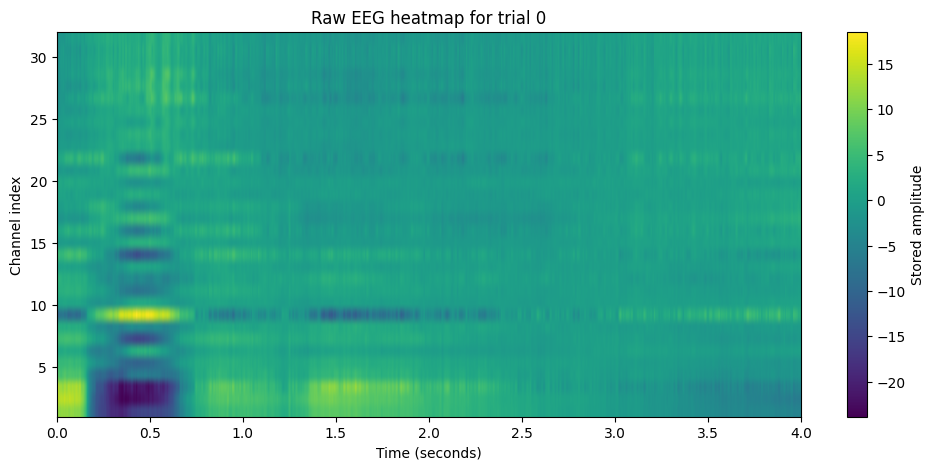

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
image = ax.imshow(
    trial, aspect="auto", origin="lower", extent=[0, WINDOW_SECONDS, 1, trial.shape[0]]
)
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Channel index")
ax.set_title(f"Raw EEG heatmap for trial {TRIAL_INDEX}")
fig.colorbar(image, ax=ax, label="Stored amplitude")
plt.show()

## 5. Frequency-domain exploration

EEG is often interpreted by frequency bands. Approximate conventional bands are:

| Band | Frequency |
|---|---:|
| Delta | 1–4 Hz |
| Theta | 4–8 Hz |
| Alpha / mu | 8–13 Hz |
| Beta | 13–30 Hz |
| Low gamma | 30–45 Hz |

Motor imagery is often associated with changes in mu and beta rhythms, but this exploratory notebook does not perform statistical inference or claim that a single session must show a clean class difference.

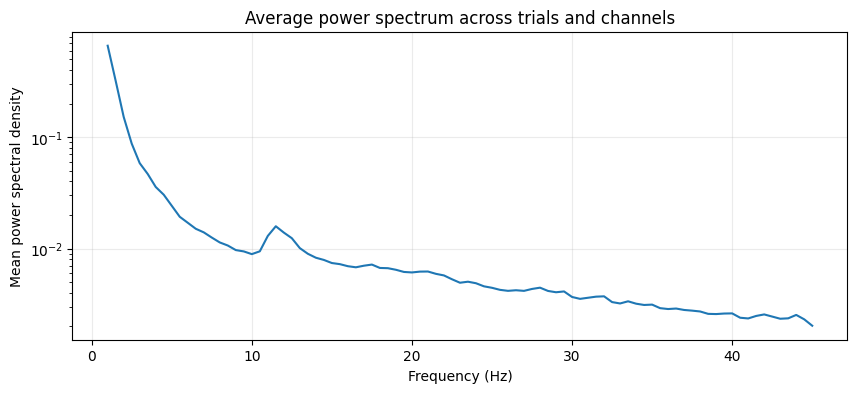

In [9]:
frequencies, psd = signal.welch(
    raw_eeg,
    fs=RAW_SAMPLING_RATE,
    nperseg=min(500, raw_eeg.shape[-1]),
    axis=-1,
)
# psd shape: [trial, channel, frequency]
mean_psd = psd.mean(axis=(0, 1))

mask = (frequencies >= 1) & (frequencies <= 45)
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(frequencies[mask], mean_psd[mask])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Mean power spectral density")
ax.set_title("Average power spectrum across trials and channels")
ax.grid(True, alpha=0.25)
plt.show()

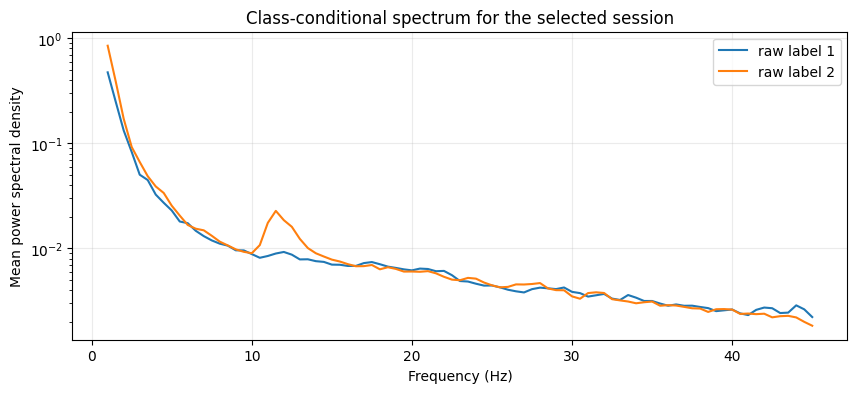

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
for label_value in sorted(np.unique(raw_labels)):
    label_psd = psd[raw_labels == label_value].mean(axis=(0, 1))
    ax.semilogy(
        frequencies[mask],
        label_psd[mask],
        label=f"raw label {label_value}",
    )
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Mean power spectral density")
ax.set_title("Class-conditional spectrum for the selected session")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

In [11]:
BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha_mu": (8, 13),
    "beta": (13, 30),
    "low_gamma": (30, 45),
}


def integrate_band(power: np.ndarray, low: float, high: float) -> np.ndarray:
    band_mask = (frequencies >= low) & (frequencies < high)
    return np.trapezoid(power[..., band_mask], frequencies[band_mask], axis=-1)


rows = []
for label_value in sorted(np.unique(raw_labels)):
    label_power = psd[raw_labels == label_value]
    for band_name, (low, high) in BANDS.items():
        values = integrate_band(label_power, low, high)
        rows.append(
            {
                "raw_label": int(label_value),
                "band": band_name,
                "mean_power": float(values.mean()),
                "median_power": float(np.median(values)),
            }
        )

band_power = pd.DataFrame(rows)
band_power.pivot(index="band", columns="raw_label", values="mean_power")

raw_label,1,2
band,,
alpha_mu,0.041656,0.061074
beta,0.095155,0.098866
delta,0.387467,0.584677
low_gamma,0.042872,0.040897
theta,0.067787,0.076377


## 6. Channel relationships and simple quality diagnostics

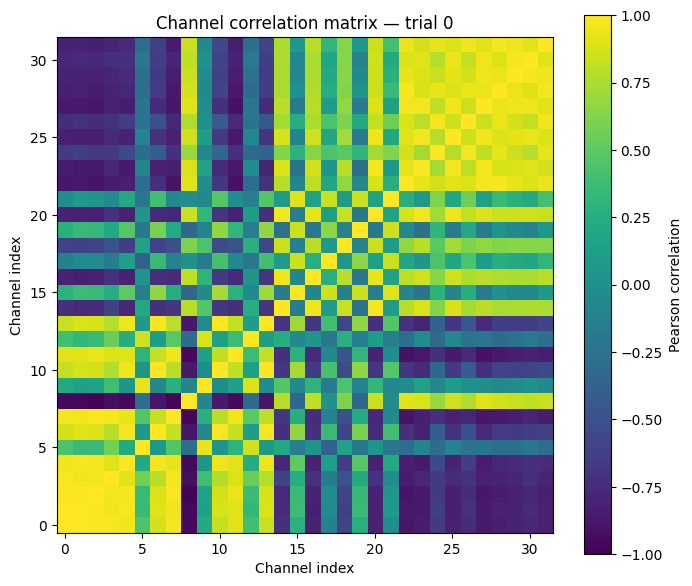

In [12]:
channel_names = [f"Ch{index + 1:02d}" for index in range(raw_eeg.shape[1])]
correlation = np.corrcoef(trial)

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(correlation, vmin=-1, vmax=1, origin="lower")
ax.set_title(f"Channel correlation matrix — trial {TRIAL_INDEX}")
ax.set_xlabel("Channel index")
ax.set_ylabel("Channel index")
fig.colorbar(image, ax=ax, label="Pearson correlation")
plt.show()

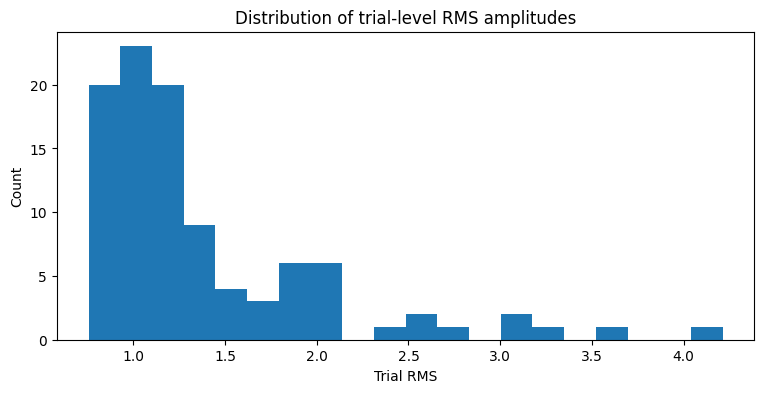

,trial,raw_label,rms,absolute_peak
84,84,2,1.413748,36.411369
58,58,2,2.087493,29.280169
16,16,2,3.089119,28.575684
37,37,2,4.212633,28.438593
81,81,2,1.229214,28.173553
45,45,1,2.537388,27.873316
42,42,2,2.043473,25.524948
6,6,2,2.802704,24.540182
0,0,1,3.223185,23.864792
47,47,2,2.024612,22.610592


In [13]:
trial_rms = np.sqrt(np.mean(np.square(raw_eeg), axis=(1, 2)))
trial_peak = np.max(np.abs(raw_eeg), axis=(1, 2))
quality = pd.DataFrame(
    {
        "trial": np.arange(len(raw_eeg)),
        "raw_label": raw_labels,
        "rms": trial_rms,
        "absolute_peak": trial_peak,
    }
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(quality["rms"], bins=20)
ax.set_xlabel("Trial RMS")
ax.set_ylabel("Count")
ax.set_title("Distribution of trial-level RMS amplitudes")
plt.show()

quality.sort_values("absolute_peak", ascending=False).head(10)

These diagnostics are not an artifact-removal pipeline. They are intended to reveal obvious problems such as unusually large peaks, flat channels, inconsistent shapes, or a session whose amplitude distribution differs substantially from the rest of the dataset.

## 7. Build or locate the processed HDF5 dataset

In [14]:
if FULL_PROCESSED_PATH.exists():
    processed_path = FULL_PROCESSED_PATH
    print(f"Using full processed dataset: {processed_path}")
else:
    processed_path = SAMPLE_PROCESSED_PATH
    if not processed_path.exists():
        processed_path.parent.mkdir(parents=True, exist_ok=True)
        summary = preprocess_shu(
            SHU_RAW_DIR,
            processed_path,
            overwrite=True,
        )
        print("Created exploration dataset:", summary)
    else:
        print(f"Using existing exploration dataset: {processed_path}")

processed_audit = audit_shu_h5(processed_path)
display(pd.Series(processed_audit.to_dict(), name="value").to_frame())

Created exploration dataset: PreprocessingSummary(source_files=1, examples=100, channels=32, original_points=1000, target_points=800, output_path='/mnt/data/cbramod_nb_src/cbramod_reproduction/data/exploration/shu_mi_sample.h5')


,value
path,/mnt/data/cbramod_nb_src/cbramod_reproduction/...
examples,100
channels,32
points,800
split_examples,"{'train': 100, 'val': 0, 'test': 0}"
split_subjects,"{'train': [1], 'val': [], 'test': []}"
split_class_counts,"{'train': {'0': 50, '1': 50}, 'val': {'0': 0, ..."
complete_subject_protocol,False
paper_protocol_ready,False
expected_paper_examples,11988


The processed file is one HDF5 container with:

```text
signals       [examples, 32, 800]
labels        [examples]
subject_ids   [examples]
session_ids   [examples]
trial_ids     [examples]
source_files  [examples]
splits/
    train     indices
    val       indices
    test      indices
```

The HDF5 file stores each trial once. Train/validation/test groups contain integer row indices rather than copies of the signal.

In [15]:
with h5py.File(processed_path, "r") as handle:
    layout_rows = []

    def visit(name: str, obj: h5py.Dataset | h5py.Group) -> None:
        if isinstance(obj, h5py.Dataset):
            layout_rows.append(
                {
                    "name": name,
                    "shape": tuple(obj.shape),
                    "dtype": str(obj.dtype),
                    "compression": obj.compression,
                    "chunks": obj.chunks,
                }
            )

    handle.visititems(visit)
    attributes = dict(handle.attrs)

print("File attributes:")
display(pd.Series(attributes, name="value").to_frame())
print("Datasets:")
display(pd.DataFrame(layout_rows))

File attributes:


,value
amplitude_scale,100.0
dataset,SHU-MI
original_sampling_rate,250
schema_version,1.0
source_file_count,1
split_protocol,"subjects 1-15 train, 16-20 val, 21-25 test"
target_sampling_rate,200
window_seconds,4.0


Datasets:


,name,shape,dtype,compression,chunks
0,labels,"(100,)",int8,None,"(1024,)"
1,session_ids,"(100,)",int16,None,"(1024,)"
2,signals,"(100, 32, 800)",float32,gzip,"(1, 32, 800)"
3,source_files,"(100,)",object,None,"(1024,)"
4,splits/test,"(0,)",int64,None,None
5,splits/train,"(100,)",int64,None,None
6,splits/val,"(0,)",int64,None,None
7,subject_ids,"(100,)",int16,None,"(1024,)"
8,trial_ids,"(100,)",int32,None,"(1024,)"


### Inspect processed metadata by split

In [16]:
with h5py.File(processed_path, "r") as handle:
    labels = np.asarray(handle["labels"], dtype=int)
    subjects = np.asarray(handle["subject_ids"], dtype=int)
    sessions = np.asarray(handle["session_ids"], dtype=int)
    trial_ids = np.asarray(handle["trial_ids"], dtype=int)
    source_files = np.asarray(handle["source_files"]).astype(str)

    processed_rows = []
    for split_name in ("train", "val", "test"):
        indices = np.asarray(handle[f"splits/{split_name}"], dtype=int)
        for index in indices:
            processed_rows.append(
                {
                    "row": int(index),
                    "split": split_name,
                    "subject": int(subjects[index]),
                    "session": int(sessions[index]),
                    "trial": int(trial_ids[index]),
                    "label": int(labels[index]),
                    "source_file": source_files[index],
                }
            )

processed_manifest = pd.DataFrame(processed_rows)
processed_manifest.head()

,row,split,subject,session,trial,label,source_file
0,0,train,1,1,0,0,sub-001_ses-01_task_motorimagery_eeg.mat
1,1,train,1,1,1,0,sub-001_ses-01_task_motorimagery_eeg.mat
2,2,train,1,1,2,1,sub-001_ses-01_task_motorimagery_eeg.mat
3,3,train,1,1,3,0,sub-001_ses-01_task_motorimagery_eeg.mat
4,4,train,1,1,4,0,sub-001_ses-01_task_motorimagery_eeg.mat


In [17]:
if not processed_manifest.empty:
    display(
        processed_manifest.groupby("split")
        .agg(
            examples=("row", "count"),
            subjects=("subject", "nunique"),
            sessions=("session", "nunique"),
            class_0=("label", lambda values: int((values == 0).sum())),
            class_1=("label", lambda values: int((values == 1).sum())),
        )
        .reindex(["train", "val", "test"])
        .fillna(0)
        .astype(int)
    )

,examples,subjects,sessions,class_0,class_1
split,,,,,
train,100,1,1,50,50
val,0,0,0,0,0
test,0,0,0,0,0


## 8. From raw trial to model-ready tensor

In [18]:
train_dataset = SHUH5Dataset(processed_path, "train")
model_eeg, model_label = train_dataset[0]

print(f"Dataset sample shape: {tuple(model_eeg.shape)}")
print(f"Dataset target:       {model_label.item()}")
print(
    f"Stored/model scale:   divided by amplitude_scale={train_dataset.amplitude_scale}"
)

# Both models receive the same 32 × 800 numbers.
simpleconv_input = model_eeg
cbramod_input = model_eeg.reshape(model_eeg.shape[0], 4, 200)

print(f"EEGSimpleConv view: {tuple(simpleconv_input.shape)}  [channel, time]")
print(
    f"CBraMod view:       {tuple(cbramod_input.shape)}  [channel, patch, samples/patch]"
)
print(
    "Representations preserve identical values:",
    bool(
        np.array_equal(cbramod_input.numpy().reshape(32, 800), simpleconv_input.numpy())
    ),
)

Dataset sample shape: (32, 800)
Dataset target:       0
Stored/model scale:   divided by amplitude_scale=100.0
EEGSimpleConv view: (32, 800)  [channel, time]
CBraMod view:       (32, 4, 200)  [channel, patch, samples/patch]
Representations preserve identical values: True


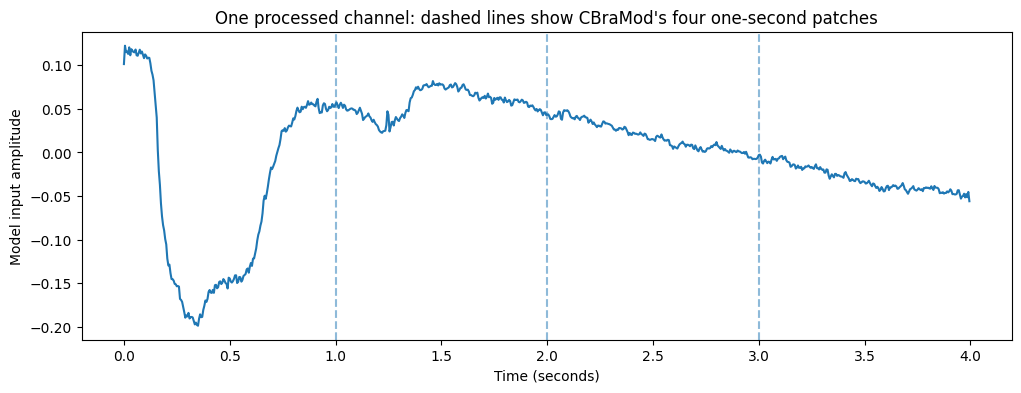

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.arange(800) / TARGET_SAMPLING_RATE, simpleconv_input[0].numpy())
for boundary in (1, 2, 3):
    ax.axvline(boundary, linestyle="--", alpha=0.5)
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Model input amplitude")
ax.set_title(
    "One processed channel: dashed lines show CBraMod's four one-second patches"
)
plt.show()

### What each model sees

**EEGSimpleConv** receives the full four-second sequence directly:

```text
batch × 32 channels × 800 samples
```

It then resamples internally from 200 Hz to 80 Hz before its convolutional stack.

**CBraMod** reshapes the same sequence into four one-second patches:

```text
batch × 32 channels × 4 patches × 200 samples
```

No information is added or removed by this reshape. It only changes how the architecture indexes time.

## 9. Optional: inspect a small HBN/BIDS sample

In [20]:
def discover_hbn_eeg_files(root: Path) -> list[Path]:
    patterns = ("**/*_eeg.set", "**/*_eeg.bdf", "**/*_eeg.edf")
    files: list[Path] = []
    for pattern in patterns:
        files.extend(root.glob(pattern))
    return sorted(set(files))


if HBN_ROOT is None or not HBN_ROOT.exists():
    display(
        Markdown(
            "HBN is not configured. Set `HBN_ROOT=/path/to/hbn` before launching the "
            "notebook to activate this section. The rest of the notebook is fully functional "
            "without HBN."
        )
    )
else:
    hbn_files = discover_hbn_eeg_files(HBN_ROOT)
    print(f"Discovered {len(hbn_files)} EEG files")
    display(
        pd.DataFrame(
            {"path": [str(path.relative_to(HBN_ROOT)) for path in hbn_files[:20]]}
        )
    )

HBN is not configured. Set `HBN_ROOT=/path/to/hbn` before launching the notebook to activate this section. The rest of the notebook is fully functional without HBN.

In [21]:
if HBN_ROOT is not None and HBN_ROOT.exists():
    hbn_files = discover_hbn_eeg_files(HBN_ROOT)
    if hbn_files:
        import mne

        hbn_path = hbn_files[0]
        suffix = hbn_path.suffix.lower()
        if suffix == ".set":
            hbn_raw = mne.io.read_raw_eeglab(hbn_path, preload=False, verbose=False)
        elif suffix == ".bdf":
            hbn_raw = mne.io.read_raw_bdf(hbn_path, preload=False, verbose=False)
        elif suffix == ".edf":
            hbn_raw = mne.io.read_raw_edf(hbn_path, preload=False, verbose=False)
        else:
            raise ValueError(f"Unsupported EEG suffix: {suffix}")

        hbn_summary = pd.Series(
            {
                "file": str(hbn_path),
                "channels": len(hbn_raw.ch_names),
                "sampling_rate_hz": float(hbn_raw.info["sfreq"]),
                "samples": int(hbn_raw.n_times),
                "duration_seconds": float(hbn_raw.n_times / hbn_raw.info["sfreq"]),
                "channel_types": Counter(hbn_raw.get_channel_types()),
                "annotations": len(hbn_raw.annotations),
            },
            name="value",
        )
        display(hbn_summary.to_frame())

        seconds_to_show = min(4.0, hbn_raw.n_times / hbn_raw.info["sfreq"])
        stop = int(seconds_to_show * hbn_raw.info["sfreq"])
        hbn_segment = hbn_raw.get_data(start=0, stop=stop)
        visible_channels = min(8, hbn_segment.shape[0])
        segment = hbn_segment[:visible_channels]
        segment_z = (segment - segment.mean(axis=1, keepdims=True)) / (
            segment.std(axis=1, keepdims=True) + 1e-12
        )
        times = np.arange(stop) / hbn_raw.info["sfreq"]
        offsets = np.arange(visible_channels)[::-1] * 5.0

        fig, ax = plt.subplots(figsize=(12, 6))
        for channel_index in range(visible_channels):
            ax.plot(times, segment_z[channel_index] + offsets[channel_index])
        ax.set_yticks(offsets, hbn_raw.ch_names[:visible_channels])
        ax.set_xlabel("Time (seconds)")
        ax.set_title("First HBN recording: standardized traces for display")
        plt.show()
    else:
        display(Markdown("No `_eeg.set`, `_eeg.bdf`, or `_eeg.edf` files were found."))

## 10. What to take away

After running this notebook on the full archive, you should be able to answer:

1. How many subjects, sessions, files, and trials are present?
2. Does every subject have the expected number of sessions and examples?
3. Are both classes balanced globally and within each split?
4. Are all files consistently shaped as `[trials, 32, 1000]`?
5. Do signals contain extreme peaks, flat trials, or suspicious amplitude shifts?
6. What frequency content is visible, especially in the 8–30 Hz range?
7. How does the raw 250 Hz signal become a 200 Hz, 800-point model example?
8. Why are the CBraMod and EEGSimpleConv inputs scientifically comparable?
9. Which information is missing from the raw files—especially channel names and units?
10. Which metadata must a future SHU-MI/HBN canonical schema preserve?

### Suggested next exploration

Once channel names are obtained, add montage-aware visualizations and class-conditional analyses around motor-cortex electrodes. Until then, channel-index plots are safer than assigning potentially incorrect anatomical labels.